# **1. Imports & Global Parameters**

In [4]:
import os # OS操作ライブラリ
import pickle # オブジェクト保存・読込ライブラリ
import numpy as np # 数値計算ライブラリ
import pandas as pd # データ分析ライブラリ
from scipy import stats # 統計ライブラリ
from sklearn.model_selection import train_test_split # データ分割用
from sklearn.preprocessing import StandardScaler # 標準化用
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc # 評価指標計算用
import matplotlib.pyplot as plt # 描画ライブラリ
import seaborn as sns # 描画ライブラリ
import tensorflow as tf # 深層学習ライブラリ
from tensorflow.keras import Sequential # 逐次モデル用
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, Dropout, Flatten, Dense, Input, GlobalAveragePooling1D # CNNレイヤー
from tensorflow.keras.optimizers import Adam # 最適化アルゴリズム
from tensorflow.keras.callbacks import EarlyStopping # 早期終了用
from sklearn.utils import resample, shuffle # サンプリング・シャッフル用
from sklearn.utils.class_weight import compute_class_weight # クラス重み計算用

DATASET_DIR = r"./WESAD" # データセットのディレクトリ
WINDOW_SECONDS = 5 # 切り出すウィンドウの長さ（秒）
FS = 700 # サンプリング周波数 (Hz)
WINDOW_SIZE = WINDOW_SECONDS * FS # 1ウィンドウあたりのサンプル数
NUM_CHANNELS = 8 # 特徴量の数 (ECG, EDA, EMG, Resp, Temp, ACC x,y,z)


I0000 00:00:1775412957.244674 4009980 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775412964.570827 4009980 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775412992.656400 4009980 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# **2. Load All .pkl Files into Memory**

In [5]:
wesad_data = {} # データを格納する辞書を初期化
for subj in os.listdir(DATASET_DIR): # 各被験者ディレクトリに対してループ
    subj_path = os.path.join(DATASET_DIR, subj) # ディレクトリパスを作成
    if not os.path.isdir(subj_path): # ディレクトリでない場合はスキップ
        continue
    for fname in os.listdir(subj_path): # ディレクトリ内のファイルをループ
        if fname.endswith('.pkl'): # .pklファイルを探す
            with open(os.path.join(subj_path, fname), 'rb') as f: # ファイルを読込モードで開く
                data = pickle.load(f, encoding='latin1') # データをロード
            wesad_data[subj] = data # 辞書に格納

print("Loaded subjects:", list(wesad_data.keys())) # ロードされた被験者リストを表示


/tmp/ipykernel_4009980/2075163656.py:9: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding='latin1') # データをロード


Loaded subjects: ['S11', 'S7', 'S3', 'S10', 'S14', 'S17', 'S4', 'S13', 'S6', 'S2', 'S16', 'S9', 'S8', 'S5', 'S15']


# **3. Build a Single DataFrame from Chest Signals**

In [6]:
data_list = [] # 各被験者のデータを格納するリスト
for subj, data in wesad_data.items(): # 辞書の各被験者データをループ
    chest = data['signal']['chest'] # 胸部センサーのデータを取得
    labels = data['label'].flatten() # ラベルを1次元配列に変換
    n = len(chest['ECG'].flatten()) # データ長を取得
    df_ch = pd.DataFrame({ # データフレームを作成
        'ECG':   chest['ECG'].flatten(), # 心電図
        'EDA':   chest['EDA'].flatten(), # 皮膚電気活動
        'EMG':   chest['EMG'].flatten(), # 筋電図
        'TEMP':  chest['Temp'].flatten(), # 温度
        'RESP':  chest['Resp'].flatten(), # 呼吸
        'ACC_X': chest['ACC'][:, 0].flatten(), # 加速度X
        'ACC_Y': chest['ACC'][:, 1].flatten(), # 加速度Y
        'ACC_Z': chest['ACC'][:, 2].flatten(), # 加速度Z
        'Label': labels[:n] # ラベル
    })
    df_ch['Subject'] = subj # 被験者IDを列として追加
    data_list.append(df_ch) # リストに追加

df = pd.concat(data_list, ignore_index=True) # 全データを1つのデータフレームに統合
df.head() # データの先頭を表示


KeyboardInterrupt: 

# **4. Filter & Map to Binary Stress Label**

In [5]:
# 特定のラベル（1:ベースライン, 2:ストレス, 3:娯楽, 4:瞑想）のみを抽出
df_filtered = df[df['Label'].isin([1, 2, 3, 4])].copy()
# ラベルをバイナリに変換: 2(ストレス) -> 1, その他 -> 0
label_map = {1: 0, 2: 1, 3: 0, 4: 0}
df_filtered['Binary_Label'] = df_filtered['Label'].map(label_map)
df_filtered.drop(columns='Label', inplace=True)
df_filtered['Binary_Label'].value_counts()

Binary_Label
0    24494402
1     6976201
Name: count, dtype: int64

## **Visualize Class Distribution**

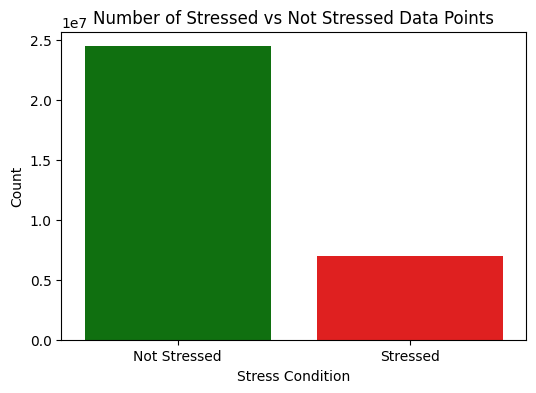

In [6]:
# 可視化のための図の設定
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df_filtered,
    x="Binary_Label",
    hue="Binary_Label",
    palette=["green", "red"],
    dodge=False
)
ax.legend_.remove()
plt.xticks([0, 1], ["Not Stressed", "Stressed"])
plt.title("Number of Stressed vs Not Stressed Data Points")
plt.xlabel("Stress Condition")
plt.ylabel("Count")
plt.show()

## **Plot an Example ECG Signal**

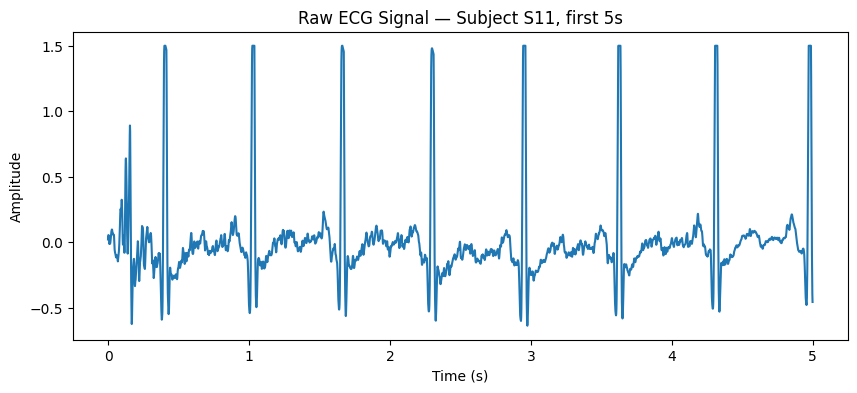

In [8]:
# pick first subject and first WINDOW_SECONDS of ECG
subj0 = list(wesad_data.keys())[0]
ecg = wesad_data[subj0]['signal']['chest']['ECG'].flatten()
t = np.arange(len(ecg)) / FS

plt.figure(figsize=(10, 4))
plt.plot(t[:WINDOW_SIZE], ecg[:WINDOW_SIZE])
plt.title(f'Raw ECG Signal — Subject {subj0}, first {WINDOW_SECONDS}s')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

## **Visualize Frequency Spectrum of an Example ECG Window**

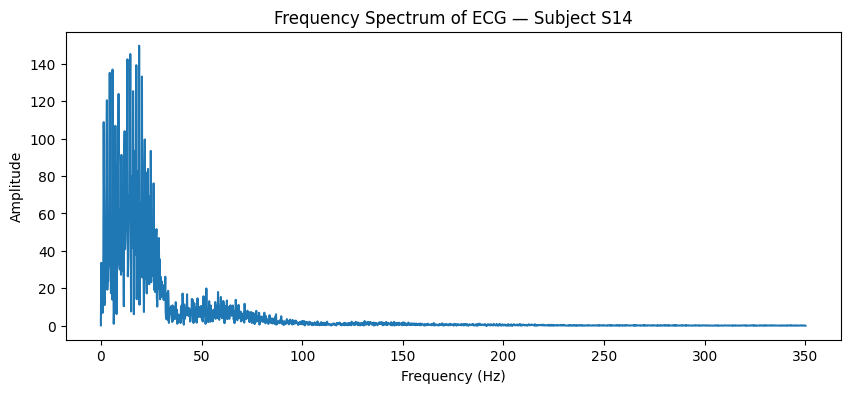

In [8]:
# pick the same first WINDOW_SECONDS of ECG we plotted before
window_ecg = ecg[:WINDOW_SIZE]

# compute FFT
fft_vals = np.fft.rfft(window_ecg)
freqs = np.fft.rfftfreq(WINDOW_SIZE, d=1/FS)

plt.figure(figsize=(10,4))
plt.plot(freqs, np.abs(fft_vals))
plt.title(f'Frequency Spectrum of ECG — Subject {subj0}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()

# **5. Data Segmentation Functions**

In [1]:
# 生信号データを固定サイズのウィンドウに分割する関数
def segment_data_raw(data_dict):
    X, y = [], []   #結果を入れる空リストの作成．Xはセンサーデータ，yは正解ラベル用
    if 'signal' not in data_dict or 'label' not in data_dict:
        return np.array([]), np.array([])
    chest = data_dict['signal']['chest']
    total_samples = len(next(iter(chest.values()))) #iter(...)データの集まりを一つずつ取り出せる状態(イテレータ)に変換する．(リストにする)
    num_windows = total_samples // WINDOW_SIZE  # //演算子は余りなし商　ウィンドウサイズ(5秒間)で全体を割って，何個塊ができるか
    for i in range(num_windows):
        start = i * WINDOW_SIZE
        end = start + WINDOW_SIZE
        window_data, label = get_window(chest, data_dict['label'], start, end)
        if window_data is not None:
            X.append(window_data)
            y.append(label)
    return np.array(X), np.array(y)
# データを切り取るプログラム
def get_window(chest, label_arr, start, end):
    def get_signal(key):
        s = np.array(chest.get(key, np.zeros(WINDOW_SIZE))[start:end]).ravel()  #特定のセンサーデータを取り出し，startからendまでを切り抜き，１次元の形に整えている．もしそのセンサーが見つからなかった場合、エラーで止まるのではなく、代わりに「0で埋まった5秒分の配列（np.zeros）」を返す
        if len(s) < WINDOW_SIZE:
            s = np.pad(s, (0, WINDOW_SIZE - len(s)))
        return s

    try:
        ECG  = get_signal('ECG')
        EDA  = get_signal('EDA')
        EMG  = get_signal('EMG')
        Resp = get_signal('Resp')
        Temp = get_signal('Temp')
        acc  = np.array(chest.get('ACC', np.zeros((WINDOW_SIZE, 3)))[start:end])
        if acc.ndim == 2 and acc.shape[1] == 3:
            ACC_x, ACC_y, ACC_z = acc[:,0], acc[:,1], acc[:,2]
        else:
            ACC_x = ACC_y = ACC_z = np.zeros(WINDOW_SIZE)

        signals = [ECG, EDA, EMG, Resp, Temp, ACC_x, ACC_y, ACC_z]
        window_data = np.stack(signals, axis=-1)
        # 最頻値を取り出す．stats.mode(..., keepdims=True)で統計学の最頻値(Mode)を取り出す，結果の形式が少し特殊なため，.mode[0]をつけて，最頻値の数値そのものを取り出せる．
        mode_label = int(stats.mode(label_arr[start:end], keepdims=True).mode[0])
        return window_data, mode_label
    except Exception as e:
        print(f"Error at window {start}: {e}")
        return None, None

# **6. Subject-Level Preprocessing & Scaling**

In [2]:
# ラベルをバイナリ（ストレスか否か）にマッピングする関数
def filter_map_labels_binary(X, y):
    valid = np.isin(y, [1, 2, 3, 4]) # ラベル y の中に 1, 2, 3, 4 が含まれているかチェックし、真偽値（True/False）のリストを作る
    X, y = X[valid], y[valid] # valid が True の行だけを残します。これで「未定義(0)」などの不要なデータを捨てます。
    mapping = {1:0, 2:1, 3:0, 4:0} # 2(ストレス)のみを1に、他を0に
    y_mapped = np.array([mapping[val] for val in y]) # 全ラベルyに対して，mappingを適用して，新しい0,1の配列を作る
    return X[:len(y_mapped)], y_mapped

# フォルダから被験者データを読み込み分割する関数
def load_subject_data(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.pkl')]
    if not files:
        return np.array([]), np.array([])
    try:
        with open(os.path.join(folder, files[0]), 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        return segment_data_raw(data)
    except Exception as e:
        print(f"Skip {folder}: {e}")
        return np.array([]), np.array([])

# 全被験者のデータをロードし、スケーリング（標準化）を行う関数
def load_and_scale_all_data():
    X_list, y_list = [], []
    for subj in sorted(os.listdir(DATASET_DIR)):
        path = os.path.join(DATASET_DIR, subj)
        if not os.path.isdir(path):
            continue
        print("Processing:", subj)
        X_sub, y_sub = load_subject_data(path)
        if X_sub.size == 0:
            continue
        X_sub, y_sub = filter_map_labels_binary(X_sub, y_sub)
        # データを2次元に変換して標準化(StandardScaler)を適用．(サンプル数, 5秒分, 8種) の3次元データを、標準化ツールが扱えるように2次元（横長）に押しつぶします。
        flat = X_sub.reshape(X_sub.shape[0], -1)
        # 標準化する．（データの平均を 0、標準偏差を 1 に変換）
        scaled = StandardScaler().fit_transform(flat).astype(np.float32)
        # 標準化済みのデータを，元の3次元形状(サンプル数, 時間, チャンネル)に戻して追加
        X_list.append(scaled.reshape(-1, WINDOW_SIZE, NUM_CHANNELS))
        y_list.append(y_sub)
    if not X_list:
        return None, None
    return np.vstack(X_list), np.concatenate(y_list)


## **Visual Comparison of ECG — Stressed vs. Not Stressed**

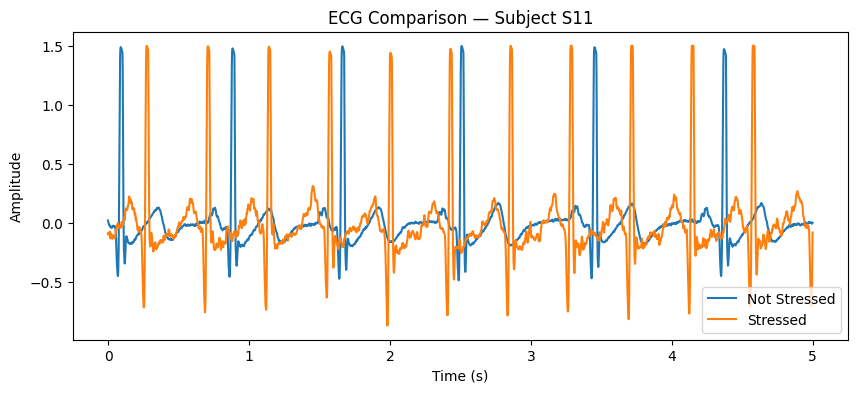

In [9]:
# 1) Segment raw data & labels for the first subject
raw_windows, raw_labels = segment_data_raw(wesad_data[subj0])

# 2) Filter & map to binary, then extract only the ECG channel (channel 0)
X_w, y_w = filter_map_labels_binary(raw_windows, raw_labels)
ecg_windows = X_w[:, :, 0]  # 8種類のデータから0番目のチャンネル（心電図 ECG）だけ抜き出す

# 3) Pick the first non-stress and first stress window
idx_non = np.where(y_w == 0)[0][0]
idx_str = np.where(y_w == 1)[0][0]

# 4) Plot both ECG waveforms over the same time axis
t = np.arange(WINDOW_SIZE) / FS
plt.figure(figsize=(10, 4))
plt.plot(t, ecg_windows[idx_non], label='Not Stressed')
plt.plot(t, ecg_windows[idx_str], label='Stressed')
plt.title(f'ECG Comparison — Subject {subj0}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

# **7. Train/Test Split**

In [12]:
# 全データをロードして標準化
X_all, y_all = load_and_scale_all_data()
if X_all is None:
    raise RuntimeError("No data loaded")

# 全データ数を出力
print("All windows:", X_all.shape[0])
# ラベルごとの出現回数を確認
print("Label counts:", dict(zip(*np.unique(y_all, return_counts=True))))

# データを学習用(70%)とテスト用(30%)に分割、シャッフルあり
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, shuffle=True
)


Processing: S10
Processing: S11
Processing: S13
Processing: S14
Processing: S15
Processing: S16
Processing: S17
Processing: S2
Processing: S3
Processing: S4
Processing: S5
Processing: S6
Processing: S7
Processing: S8
Processing: S9
All windows: 8995
Label counts: {0: 7002, 1: 1993}


# **8. Build & Compile 1D-CNN**

In [25]:
# バイナリ分類用の1D-CNNアーキテクチャを定義
def build_1d_cnn_binary(input_shape):
    return Sequential([
        Input(shape=input_shape),
        # 32のフィルタ⓪数，7の一度に見るデータ幅で，活性化関数はReLU
        Conv1D(32, 7, activation='relu', padding='same'),
        BatchNormalization(),
        # データサイズを半分に圧縮．重要な情報のみ残す
        MaxPooling1D(2),
        
        Conv1D(64, 5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(128, 3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),

        #パラメータ数が大幅に減少するため，学習速度が向上する．モデルがシンプルになるため過学習を防げる
        GlobalAveragePooling1D(),
        # 層にあるニューロンのうち，40%をランダムに選んでその甲斐の学習から除外する．
        # メリット：学習データにノイズがあるとそれすら，ストレスの原因と学習してしまう(そのノイズを過学習してしまう)
        # 特定のニューロンに頼れなくなる，重要な特徴だけ覚えるようになり，汎化性が向上する
        Dropout(0.4),
        
        # 活性化関数にはReLUを，ストレス度合いを決めるための64の複合的な判断材料を作る
        Dense(64, activation='relu'),
        Dropout(0.3),

        # 最後，0~1で確立を出す
        Dense(1, activation='sigmoid')
    ])

model = build_1d_cnn_binary((WINDOW_SIZE, NUM_CHANNELS))
# モデルのコンパイル（Adamオプティマイザ、バイナリ交差エントロピー損失）学習率0.0005
model.compile(optimizer=Adam(5e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# 1. 「層」の数え方の内訳
# 重みを持ってデータを変化させる主要な層を数えてみましょう。

# Conv1D (第1層): 32フィルターで特徴抽出

# Conv1D (第2層): 64フィルターで特徴抽出

# Conv1D (第3層): 128フィルターで特徴抽出

# Dense (第4層): 64ユニットの全結合層

# Dense (第5層): 1ユニットの出力層（最終判定）

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)                    │ (None, 3500, 32)            │           1,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 3500, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_9 (MaxPooling1D)       │ (None, 1750, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_10 (Conv1D)                   │ (None, 1750, 64)            │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 1750, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_10 (MaxPooling1D)      │ (None, 875, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_11 (Conv1D)                   │ (None, 875, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 875, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_11 (MaxPooling1D)      │ (None, 437, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_3           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 46,049 (179.88 KB)

 Trainable params: 45,601 (178.13 KB)

 Non-trainable params: 448 (1.75 KB)

# **9. Train the Model**

In [26]:
# 不均衡データに対処するため、クラス重みを計算（学習時に重みを付け、少ないクラスを重視する）
class_weights = dict(enumerate(
    compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
))
# 早期終了(EarlyStopping)の設定: 検証損失が3エポック連続で改善しなければ学習を停止
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# モデルの学習開始
history = model.fit(
    X_train, y_train, # 学習データ
    epochs=20, # 最大20エポック
    batch_size=64, # バッチサイズ
    validation_split=0.2, # 学習データの20%をバリデーションに使用
    class_weight=class_weights, # 先ほど計算したクラス重みを適用
    callbacks=[early_stop], # 早期終了を適用
    verbose=1 # 進捗を出力
)


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.8230 - loss: 0.3266 - val_accuracy: 0.9349 - val_loss: 0.3839
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9342 - loss: 0.1572 - val_accuracy: 0.9405 - val_loss: 0.1918
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9558 - loss: 0.1153 - val_accuracy: 0.9659 - val_loss: 0.1083
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9584 - loss: 0.1053 - val_accuracy: 0.9794 - val_loss: 0.0643
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9664 - loss: 0.0846 - val_accuracy: 0.9778 - val_loss: 0.0587
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9698 - loss: 0.0762 - val_accuracy: 0.9817 - val_loss: 0.0514
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9752 - loss: 0.0587 - val_accuracy: 0.9865 - val_loss: 0.0543
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9813 - loss: 0.0493 - val_accuracy: 0.9865 - 

# **10. Visualize Training Curves**

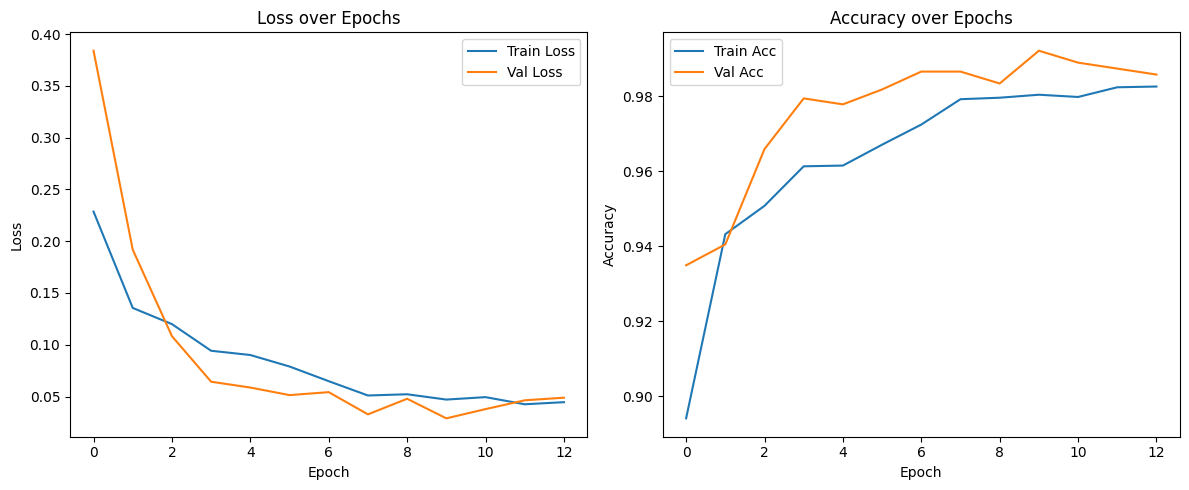

In [27]:
# 学習曲線の可視化用領域作成
plt.figure(figsize=(12,5))

# 1) 損失(Loss)のプロット
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 2) 精度(Accuracy)のプロット
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


# **11. Threshold Tuning**

In [28]:
# テストデータに対する予測確率を取得
y_probs = model.predict(X_test)
# 0.5から0.95まで0.05刻みで閾値の候補を作成
thresholds = np.arange(0.5, 1.0, 0.05)
best_thresh, best_f1 = 0.5, 0.0

# 各閾値を試して、F1スコアが最も良くなる閾値を探す
for t in thresholds:
    preds = (y_probs > t).astype(int) # 確率が閾値を超えれば1、そうでなければ0
    score = f1_score(y_test, preds) # F1スコアを算出
    if score > best_f1:
        best_f1, best_thresh = score, t # 最高値を更新

print(f"Best thresh: {best_thresh:.2f}, F1: {best_f1:.3f}")


85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Best thresh: 0.70, F1: 0.980


# **12. Final Evaluation & Confusion Matrix**

Classification Report:
              precision    recall  f1-score   support

  Non-Stress       1.00      0.99      0.99      2097
      Stress       0.98      0.99      0.98       602

    accuracy                           0.99      2699
   macro avg       0.99      0.99      0.99      2699
weighted avg       0.99      0.99      0.99      2699



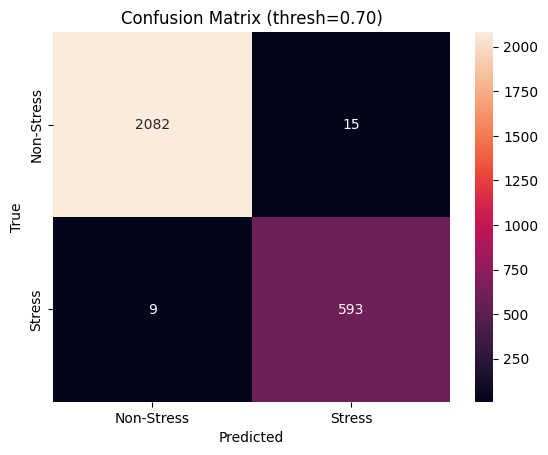

In [29]:
# 最適な閾値を用いて最終的なバイナリ予測を行う
y_pred = (y_probs > best_thresh).astype(int)

# 分類レポート（適合率、再現率、F1スコアなど）を出力
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Stress","Stress"]))

# 混同行列(Confusion Matrix)を計算
cm = confusion_matrix(y_test, y_pred)
# ヒートマップで可視化
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket',
            xticklabels=["Non-Stress","Stress"],
            yticklabels=["Non-Stress","Stress"])
plt.title(f"Confusion Matrix (thresh={best_thresh:.2f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# **13. Save the Model**

In [30]:
# 学習済みモデルをファイルに保存
model.save("final_binary_1dcnn_class_weights.h5")
print("Model saved to Binary_1DCNN_Class_Weights.h5")

Model saved to Binary_1DCNN_Class_Weights.h5


# **14. Testing the Model by Resampling Balanced Data from the Test Set**

In [31]:
# Separate classes in test set
X_test_nonstress = X_test[y_test == 0]
X_test_stress = X_test[y_test == 1]

# Downsample the majority class
if len(X_test_nonstress) > len(X_test_stress):
    X_ns_down, y_ns_down = resample(
        X_test_nonstress, np.zeros(len(X_test_nonstress)), 
        replace=False, n_samples=len(X_test_stress), random_state=42
    )
    X_test_balanced = np.concatenate([X_ns_down, X_test_stress])
    y_test_balanced = np.concatenate([y_ns_down, np.ones(len(X_test_stress))])
else:
    X_s_down, y_s_down = resample(
        X_test_stress, np.ones(len(X_test_stress)), 
        replace=False, n_samples=len(X_test_nonstress), random_state=42
    )
    X_test_balanced = np.concatenate([X_test_nonstress, X_s_down])
    y_test_balanced = np.concatenate([np.zeros(len(X_test_nonstress)), y_s_down])

# Shuffle the balanced test set
X_test_balanced, y_test_balanced = shuffle(X_test_balanced, y_test_balanced, random_state=42)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Classification Report (Balanced Test Set):
              precision    recall  f1-score   support

  Non-Stress       0.99      0.99      0.99       602
      Stress       0.99      0.99      0.99       602

    accuracy                           0.99      1204
   macro avg       0.99      0.99      0.99      1204
weighted avg       0.99      0.99      0.99      1204



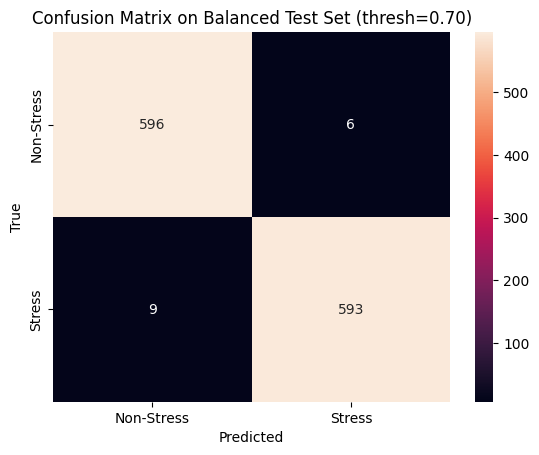

In [32]:
# Predict with the same trained model
y_probs_balanced = model.predict(X_test_balanced)
y_pred_balanced = (y_probs_balanced > best_thresh).astype(int)

#Print classification report and plot confusion matrix
print("Classification Report (Balanced Test Set):")
print(classification_report(y_test_balanced, y_pred_balanced, target_names=["Non-Stress", "Stress"]))

cm = confusion_matrix(y_test_balanced, y_pred_balanced)
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket',
            xticklabels=["Non-Stress", "Stress"],
            yticklabels=["Non-Stress", "Stress"])
plt.title(f"Confusion Matrix on Balanced Test Set (thresh={best_thresh:.2f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# **Plotting the ROC Curve**

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


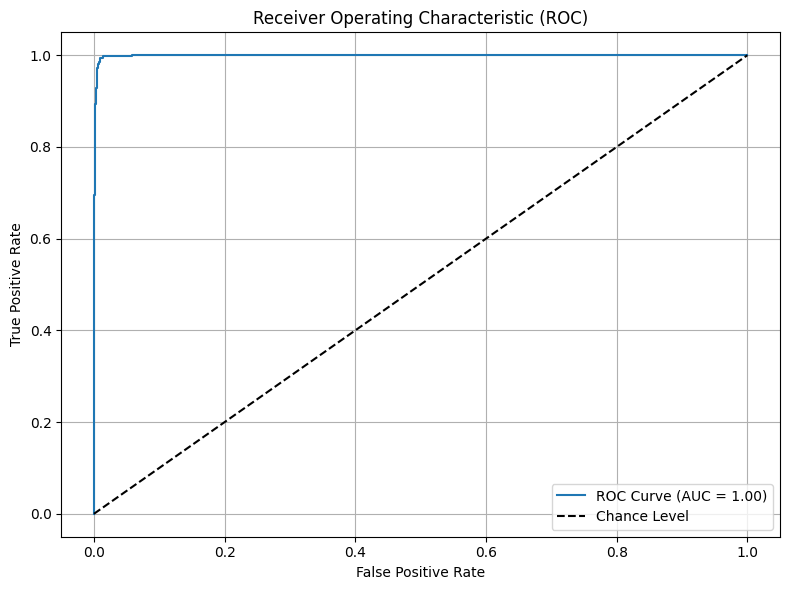

In [33]:
# Get predicted probabilities
y_pred_probs = model.predict(X_test).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance Level')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()